In [1]:
%pip install lightgbm xgboost catboost


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import joblib


from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.config import *
from src.utils import get_latest_file
pd.set_option("display.max_columns", None)

In [ ]:

bets_df, summary = run_season_simulation(["2022-23", "2023-24"])

print("\n=== Résumé des paris ===")
print(summary)
print("\n=== Détails des paris ===")
print(bets_df.head())


=== Simulation pour la saison 2022-23 ===


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC sur données d'entraînement: 0.7930

Exemples de clés de match dans odds_df (tolérance date):
0    (2023-06-12, denver nuggets, miami heat)
1    (2023-06-09, miami heat, denver nuggets)
2    (2023-06-07, miami heat, denver nuggets)
3    (2023-06-04, denver nuggets, miami heat)
4    (2023-06-01, denver nuggets, miami heat)
Name: match_key, dtype: object

Exemples de clés de match dans nba_df:
56336     (2022-10-18, boston celtics, philadelphia 76ers)
56338    (2022-10-18, golden state warriors, los angele...
56340         (2022-10-19, detroit pistons, orlando magic)
56342     (2022-10-19, indiana pacers, washington wizards)
56344         (2022-10-19, atlanta hawks, houston rockets)
Name: match_key, dtype: object

Nombre de lignes fusionnées: 5196
Nombre de correspondances réussies: 2640
Nombre de correspondances échouées: 2556

IDs manquants TEAM_ID: []
IDs manquants OPP_TEAM_ID: []
------------------ Nombre de lignes supprimées pour cotes manquantes: 4 ------------------

Match 

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC sur données d'entraînement: 0.8046

Exemples de clés de match dans odds_df (tolérance date):
0    (2024-06-17, boston celtics, dallas mavericks)
1    (2024-06-14, dallas mavericks, boston celtics)
2    (2024-06-12, dallas mavericks, boston celtics)
3    (2024-06-09, boston celtics, dallas mavericks)
4    (2024-06-06, boston celtics, dallas mavericks)
Name: match_key, dtype: object

Exemples de clés de match dans nba_df:
58976     (2023-10-24, denver nuggets, los angeles lakers)
58978    (2023-10-24, golden state warriors, phoenix suns)
58980       (2023-10-25, charlotte hornets, atlanta hawks)
58982     (2023-10-25, indiana pacers, washington wizards)
58984        (2023-10-25, new york knicks, boston celtics)
Name: match_key, dtype: object

Nombre de lignes fusionnées: 5182
Nombre de correspondances réussies: 2624
Nombre de correspondances échouées: 2558

IDs manquants TEAM_ID: []
IDs manquants OPP_TEAM_ID: []

Match 1: toronto raptors vs boston celtics (2023-11-17)
  toronto r

In [ ]:
#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)

In [5]:
bets_df

,date,team,odds,prob,ev,stake,won,gain,bankroll
0,None,miami heat,1.57,0.658302,0.033535,50.000000,1,28.500000,1028.500000
1,None,chicago bulls,1.94,0.556315,0.079252,51.425000,0,-51.425000,977.075000
2,None,houston rockets,6.85,0.172666,0.182762,30.525096,0,-30.525096,946.549904
3,None,memphis grizzlies,2.65,0.521529,0.382052,47.327495,0,-47.327495,899.222409
4,None,denver nuggets,1.19,0.748634,-0.109126,0.000000,1,0.000000,899.222409
...,...,...,...,...,...,...,...,...,...
2422,None,chicago bulls,1.58,0.626701,-0.009812,0.000000,1,0.000000,1.765018
2423,None,new orleans pelicans,1.77,0.631887,0.118440,0.088251,0,-0.088251,1.676767
2424,None,sacramento kings,2.08,0.656667,0.365868,0.083838,1,0.090545,1.767313
2425,None,miami heat,1.66,0.684102,0.135609,0.088366,1,0.058321,1.825634


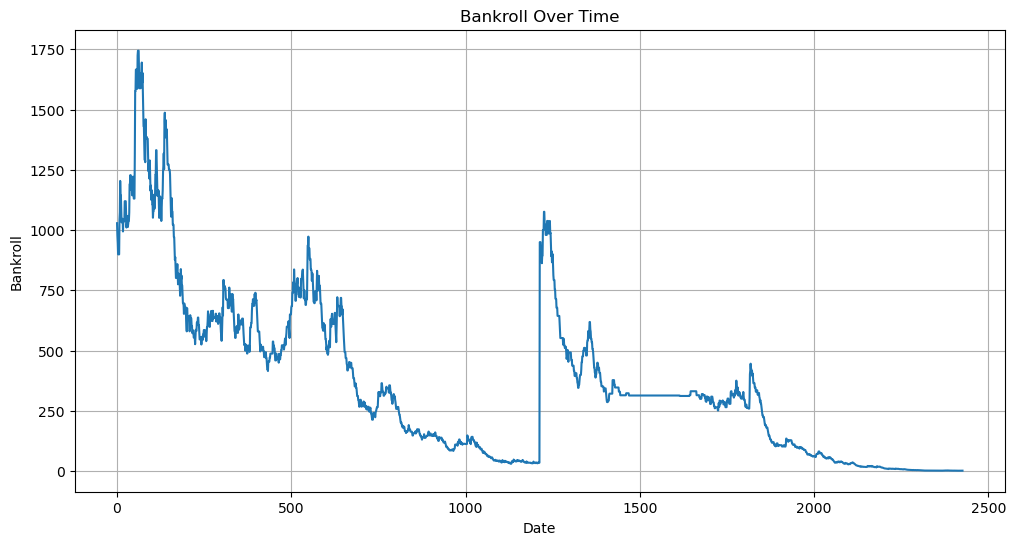

In [8]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()



